.<center>

</center>
<div style="padding:20px;color:#150d0a;margin:10px;font-size:220%;text-align:center;display:fill;border-radius:20px;border-width: 5px;border-style: solid;border-color: #150d0a;background-color:#eca912;overflow:hidden;font-weight:500">DR Detection utilizing Deep Learning Models and XAI methods</div>

# Importing libraries 📚

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os, glob
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Model, Sequential, load_model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, GlobalAveragePooling2D, Activation, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


# Load data 💾

In [14]:
data_dir = r"/kaggle/input/data-new-dr/Data_large/train"
Retanial = []
  
train_dir = "/kaggle/input/data-new-dr/Data_large/train"
val_dir = "/kaggle/input/data-new-dr/Data_large/val"


img_height, img_width = 256, 256
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,         
    width_shift_range=0.1,     
    height_shift_range=0.1,    
    horizontal_flip=True,      
    zoom_range=0.1             
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  
)

precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()

Found 5150 images belonging to 5 classes.
Found 1254 images belonging to 5 classes.


# Training the MobileNetV2 model 🚂

In [3]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(5, activation='softmax'))  
model.summary()


early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


base_model.trainable = False
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", precision, recall]
)
hist1 = model.fit(
    train_generator,
    epochs=10,  
    validation_data=val_generator,
    verbose=1,
    callbacks=[early_stopping]
)


<ipython-input-3-54dc9db24be0>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 8, 8, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,340,549 (8.93 MB)

 Trainable params: 2,306,309 (8.80 MB)

 Non-trainable params: 34,240 (133.75 KB)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 800ms/step - accuracy: 0.3344 - loss: 1.8046 - precision: 0.3773 - recall: 0.1950 - val_accuracy: 0.3456 - val_loss: 1.4154 - val_precision: 0.4937 - val_recall: 0.1797
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 396ms/step - accuracy: 0.5571 - loss: 1.1375 - precision: 0.6670 - recall: 0.4171 - val_accuracy: 0.3502 - val_loss: 1.4467 - val_precision: 0.4444 - val_recall: 0.2212
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 416ms/step - accuracy: 0.5602 - loss: 1.0713 - precision: 0.7030 - recall: 0.3973 - val_accuracy: 0.4240 - val_loss: 1.3167 - val_precision: 0.6000 - val_recall: 0.3318
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 415ms/step - accuracy: 0.5915 - loss: 1.0089 - precision: 0.7247 - recall: 0.4491 - val_accuracy: 0.5115 - val_loss: 1.1915 - val_precision: 0.5765 - val_recall: 0.4516
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 413ms/step - accuracy: 0.6191 - loss: 0.9664 - precision: 0.7091 - recall: 0.4568 - val_accuracy: 0.5622 - val_loss: 1.0915 -

In [4]:
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False  
model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss="categorical_crossentropy",
    metrics=["accuracy", precision, recall]
)
hist2 = model.fit(
    train_generator,
    epochs=40, 
    validation_data=val_generator,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 829ms/step - accuracy: 0.6850 - loss: 0.8576 - precision: 0.6224 - recall: 0.5039 - val_accuracy: 0.6590 - val_loss: 0.8914 - val_precision: 0.7237 - val_recall: 0.5069
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 405ms/step - accuracy: 0.6753 - loss: 0.8079 - precision: 0.7766 - recall: 0.5753 - val_accuracy: 0.6544 - val_loss: 0.9032 - val_precision: 0.7289 - val_recall: 0.5576
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 418ms/step - accuracy: 0.7009 - loss: 0.7509 - precision: 0.7754 - recall: 0.5905 - val_accuracy: 0.6175 - val_loss: 0.8790 - val_precision: 0.7317 - val_recall: 0.5530
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 422ms/step - accuracy: 0.7314 - loss: 0.7148 - precision: 0.8123 - recall: 0.6089 - val_accuracy: 0.6129 - val_loss: 0.9617 - val_precision: 0.6647 - val_recall: 0.5207
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 428ms/step - accuracy: 0.6989 - loss: 0.7557 - precision: 0.7939 - recall: 0.6011 - val_accuracy: 0.6406 - val_los

# Sample Predictions of MobileNetV2 model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


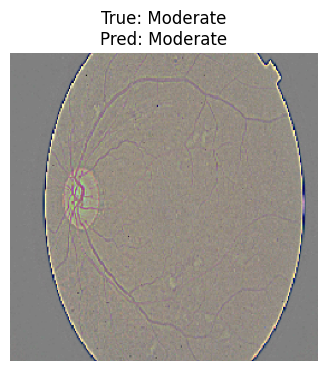

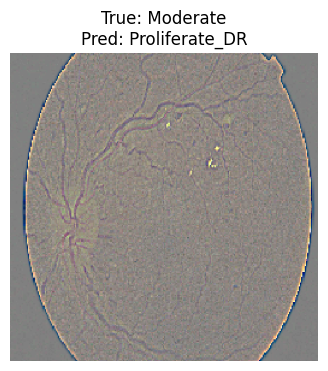

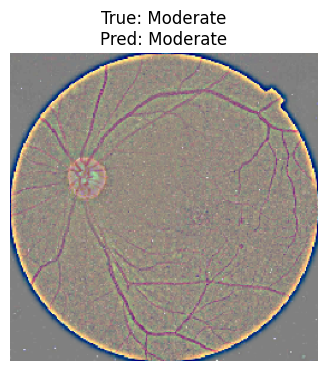

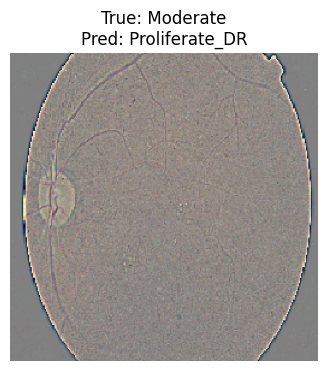

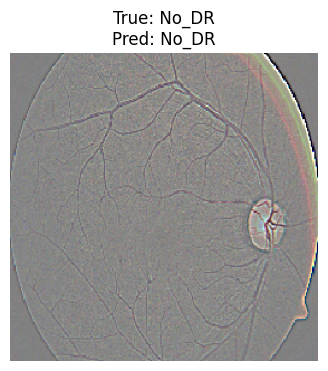

In [12]:
import matplotlib.pyplot as plt
import numpy as np

sample_val_images, sample_val_labels = next(val_generator)
predictions = model.predict(sample_val_images)
class_labels = list(val_generator.class_indices.keys()) 
for i in range(5):
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_val_images[i].clip(0, 1))  
    true_label = class_labels[np.argmax(sample_val_labels[i])]
    pred_label = class_labels[np.argmax(predictions[i])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
    plt.show()

# Performance metrics and evaluation

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 286ms/step
Accuracy: 0.7604
Precision: 0.7720
Recall: 0.7604
Specificity: 0.9402

Classification Report:
                precision    recall  f1-score   support

          Mild       0.83      0.77      0.80        78
Proliferate_DR       0.64      0.74      0.69        86
      Moderate       0.85      0.98      0.91        96
         No_DR       0.86      0.56      0.68        90
        Severe       0.66      0.74      0.70        84

      accuracy                           0.76       434
     macro avg       0.77      0.76      0.75       434
  weighted avg       0.77      0.76      0.76       434



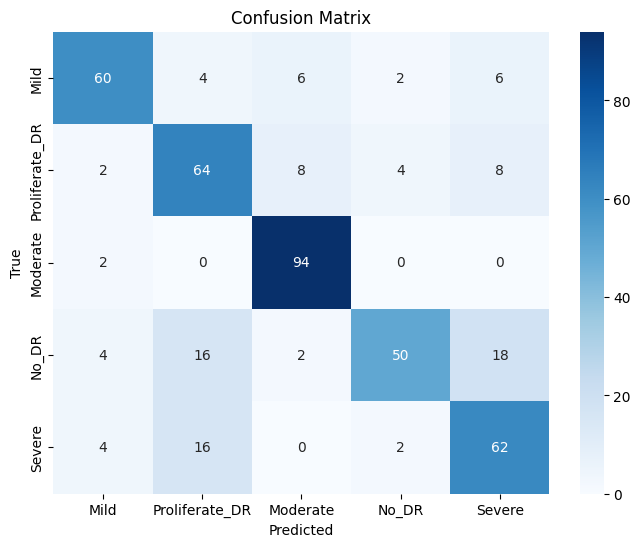


AUC-ROC Scores:
AUC-ROC for class Mild: 0.9486
AUC-ROC for class Proliferate_DR: 0.9035
AUC-ROC for class Moderate: 0.9968
AUC-ROC for class No_DR: 0.8977
AUC-ROC for class Severe: 0.9312
Average AUC-ROC: 0.9355


In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_labels = val_generator.classes

accuracy = accuracy_score(true_labels, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

precision = precision_score(true_labels, predicted_classes, average='weighted')
recall = recall_score(true_labels, predicted_classes, average='weighted')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

cm = confusion_matrix(true_labels, predicted_classes)
specificity = []
for i in range(5):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])  
    fp = cm[:, i].sum() - cm[i, i]  
    specificity.append(tn / (tn + fp))
specificity = np.mean(specificity)
print(f"Specificity: {specificity:.4f}")

report = classification_report(true_labels, predicted_classes, target_names=Retanial)
print("\nClassification Report:")
print(report)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Retanial, yticklabels=Retanial)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

y_true_bin = label_binarize(true_labels, classes=[0, 1, 2, 3, 4])
auc_scores = []
print("\nAUC-ROC Scores:")
for i in range(5):
    auc = roc_auc_score(y_true_bin[:, i], predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC-ROC for class {Retanial[i]}: {auc:.4f}")
average_auc = np.mean(auc_scores)
print(f"Average AUC-ROC: {average_auc:.4f}")